In [252]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

b_y = np.random.geometric(p=1/5) # mean = 1/p         # Mean burst size of mRNA
gamma_y = 0.0001389       # mRNA degradation rate
k_y0 = 0.0027         # Basal transcription rate

beta_s = 0.06       # Unbinding rate 
alpha_s = 0.5      # Binding propensity per site per molecule (UPDATED)
S_tot = 1        # Total Sox2 pool
k_ys = 1.0          # Transcription burst frequency boost per bound Sox2

alpha_n = 0.3      
beta_n = 0.2        # Fixed at your experimental value
N_tot = 9
k_yn = 1.0          # Transcription burst frequency boost per bound Nanog

N_S = 2             # Fixed Sox2 sites
N_N = 10            # Fixed Nanog sites



In [ ]:
def calculate_target_fano(alpha_n = 0.3, alpha_s = 0.5, beta_n = 0.2, beta_s = 0.06, N_N = 10, N_S = 2, N_tot = 9, S_tot = 1):
    b_y = np.random.geometric(p=1/5)
    p_s = (alpha_s * N_S) / (alpha_s * N_S + beta_s)
    var_s = S_tot * p_s * (1.0 - p_s)
    
    p_n = (alpha_n * N_N) / (alpha_n * N_N + beta_n)
    var_n = N_tot * p_n * (1.0 - p_n)
    
    mean_fy = k_y0 + (k_ys * S_tot * p_s) + (k_yn * N_tot * p_n)
    
    intrinsic = 1.0 + b_y
    
    ext_s = (b_y / mean_fy) * ( (k_ys**2 * var_s) / (gamma_y + alpha_s * N_S + beta_s) )
    ext_n = (b_y / mean_fy) * ( (k_yn**2 * var_n) / (gamma_y + alpha_n * N_N + beta_n) )
    
    return intrinsic + ext_s + ext_n


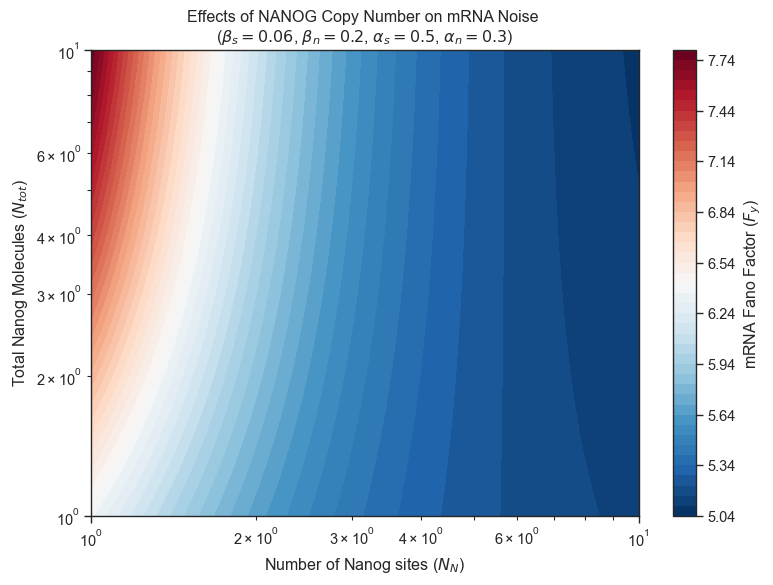

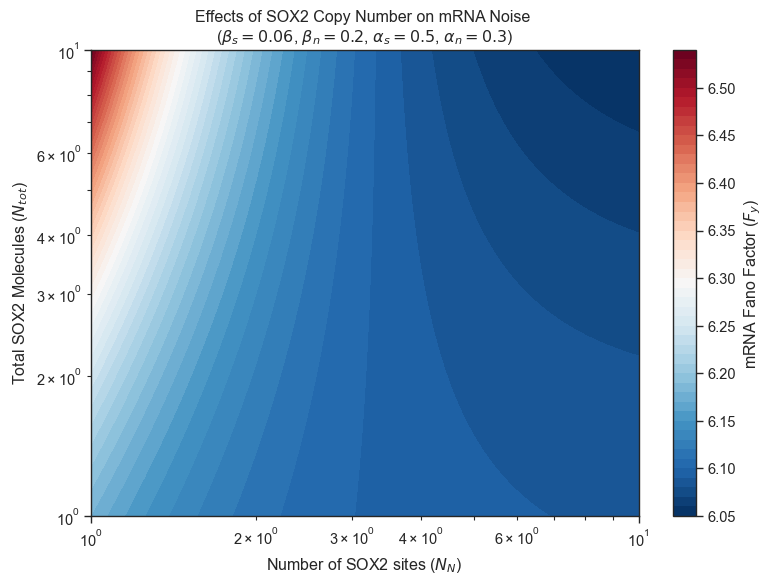

In [249]:
NN_vals = np.logspace(0, 1, 200)
Ntot_vals = np.logspace(0, 1, 200)

X_NN, Y_Ntot = np.meshgrid(NN_vals, Ntot_vals)

# Vectorize the analytical function across the grid
Fy_grid = calculate_target_fano(N_N = X_NN, N_tot = Y_Ntot)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(X_NN, Y_Ntot, Fy_grid, levels=50, cmap="RdBu_r")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('mRNA Fano Factor ($F_y$)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of Nanog sites ($N_N$)')
ax.set_ylabel('Total Nanog Molecules ($N_{tot}$)')
ax.set_title(f'Effects of NANOG Copy Number on mRNA Noise \n($\\beta_s = {beta_s}$, $\\beta_n = {beta_n}$, $\\alpha_s = {alpha_s}$, $\\alpha_n = {alpha_n}$)')

plt.tight_layout()
plt.show()

NN_vals = np.logspace(0, 1, 200)
Ntot_vals = np.logspace(0, 1, 200)

X_NN, Y_Ntot = np.meshgrid(NN_vals, Ntot_vals)

# Vectorize the analytical function across the grid
Fy_grid = calculate_target_fano(N_S = X_NN, S_tot = Y_Ntot)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(X_NN, Y_Ntot, Fy_grid, levels=50, cmap="RdBu_r")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('mRNA Fano Factor ($F_y$)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of SOX2 sites ($N_N$)')
ax.set_ylabel('Total SOX2 Molecules ($N_{tot}$)')
ax.set_title(f'Effects of SOX2 Copy Number on mRNA Noise \n($\\beta_s = {beta_s}$, $\\beta_n = {beta_n}$, $\\alpha_s = {alpha_s}$, $\\alpha_n = {alpha_n}$)')

plt.tight_layout()
plt.show()


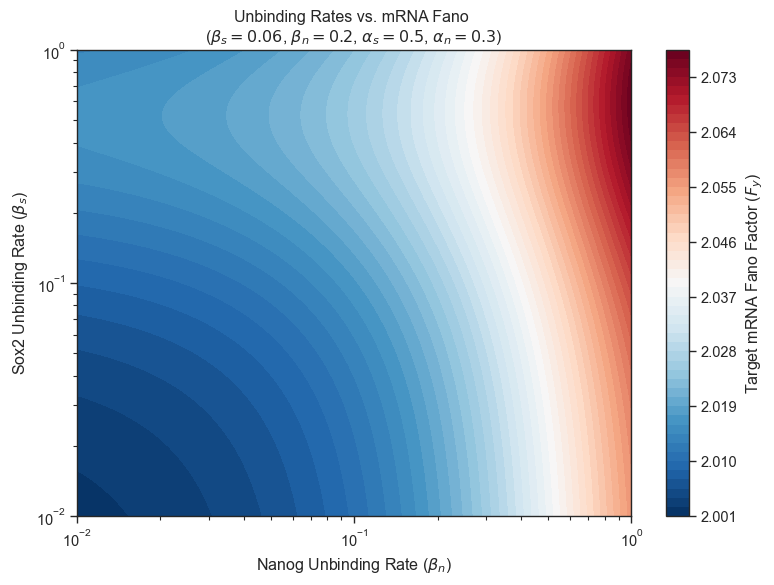

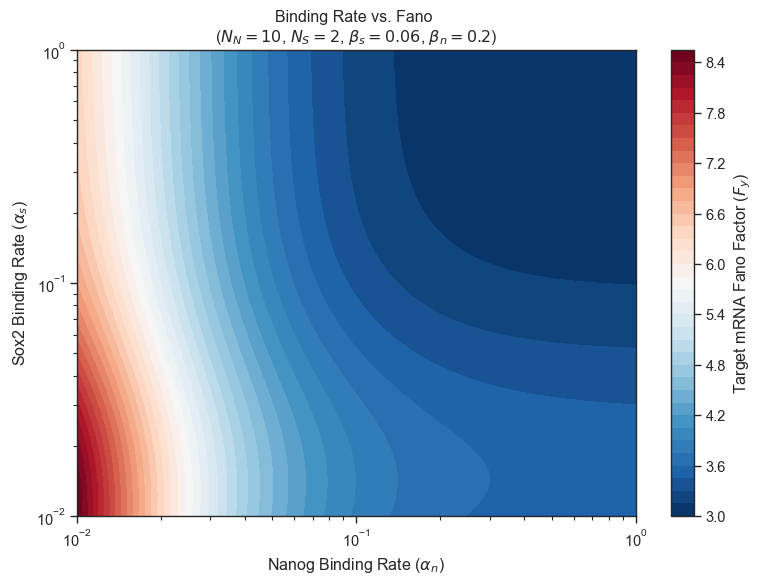

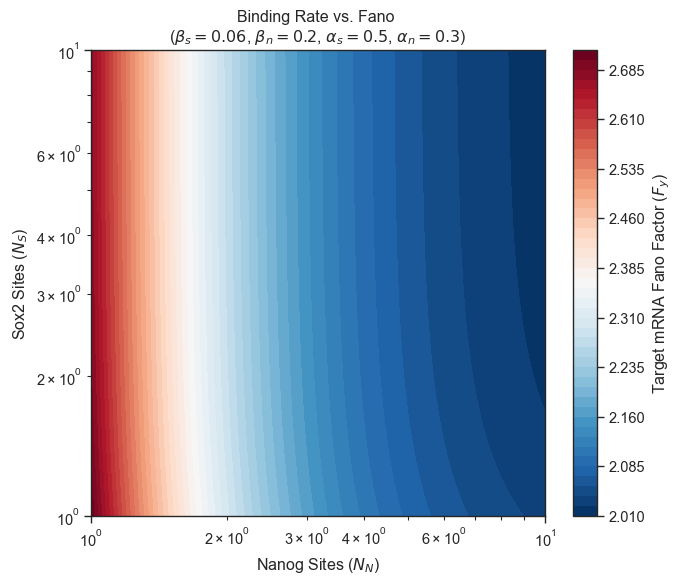

In [254]:
betan_vals = np.logspace(-2, 0, 200)
betas_vals = np.logspace(-2, 0, 200)
X_betan, Y_betas = np.meshgrid(betan_vals, betas_vals)

Fy_grid = calculate_target_fano(beta_n = X_betan, beta_s = Y_betas)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(X_betan, Y_betas, Fy_grid, levels=50, cmap="RdBu_r")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Target mRNA Fano Factor ($F_y$)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Nanog Unbinding Rate ($\\beta_n$)')
ax.set_ylabel('Sox2 Unbinding Rate ($\\beta_s$)')
ax.set_title(f'Unbinding Rates vs. mRNA Fano \n($\\beta_s = {beta_s}$, $\\beta_n = {beta_n}$, $\\alpha_s = {alpha_s}$, $\\alpha_n = {alpha_n}$)')

plt.tight_layout()
plt.show()



betan_vals = np.logspace(-2, 0, 200)
betas_vals = np.logspace(-2, 0, 200)
X_betan, Y_betas = np.meshgrid(betan_vals, betas_vals)

Fy_grid = calculate_target_fano(alpha_n = X_betan, alpha_s = Y_betas)

sns.set_theme(style="ticks", context="paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(8, 6))

contour = ax.contourf(X_betan, Y_betas, Fy_grid, levels=50, cmap="RdBu_r")
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label('Target mRNA Fano Factor ($F_y$)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Nanog Binding Rate ($\\alpha_n$)')
ax.set_ylabel('Sox2 Binding Rate ($\\alpha_s$)')
ax.set_title(f'Binding Rate vs. Fano \n($N_N={N_N}$, $N_S={N_S}$, $\\beta_s = {beta_s}$, $\\beta_n = 0.2$)')

plt.tight_layout()
plt.show()
NN_grid1 = np.logspace(0, 1, 200)
NS_grid1 = np.logspace(0, 1, 200)
X_NN1, Y_NS1 = np.meshgrid(NN_grid1, NS_grid1)

fano = calculate_target_fano(N_N=X_NN1, N_S=Y_NS1, beta_n=0.2, beta_s = 0.06)

fig1, ax1 = plt.subplots(figsize=(7, 6))
contour1 = ax1.contourf(X_NN1, Y_NS1, fano, levels=50, cmap="RdBu_r")
cbar1 = fig1.colorbar(contour1, ax=ax1)
cbar1.set_label('Target mRNA Fano Factor ($F_y$)')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Nanog Sites ($N_N$)')
ax1.set_ylabel('Sox2 Sites ($N_S$)')
ax1.set_title(f'Binding Rate vs. Fano \n($\\beta_s = {beta_s}$, $\\beta_n = {beta_n}$, $\\alpha_s = {alpha_s}$, $\\alpha_n = {alpha_n}$)')
plt.tight_layout()